# **Step 0. Mount Google Drive and Load Dataset**

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd

car_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/auto_mpg_binarised.csv')

car_data.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_high
0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,0
1,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,0
2,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,0
3,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,0
4,8,302.0,140.0,3449.0,10.5,70,1,ford torino,0


In [28]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    398 non-null    float64
 3   weight        398 non-null    float64
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   car_name      398 non-null    object 
 8   mpg_high      398 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [29]:
#Identify Numeric Columns
#Note: Some times numberic columns are categorical in nature
#example cylinders, model_year, origin
numerical_cols = numeric_cols = ['displacement', 'horsepower', 'weight', 'acceleration']
numerical_cols

['displacement', 'horsepower', 'weight', 'acceleration']

# **1. Box Plot**


# 📦 Why do we use a Box Plot in EDA?

A **Box Plot** is used to summarize the distribution of a **numerical feature**. It helps identify the **median**, **spread of the data**, and **outliers** in a single visualization.

## 🎯 Uses of Box Plot

* 📍 **Find the median**

  * Identify the middle value of the dataset.

* 📊 **Understand the data spread**

  * Check how the data is distributed using the quartiles (Q1, Q2, and Q3).

* 🚨 **Detect outliers**

  * Easily identify unusually high or low values that are far from the rest of the data.

* ⚖️ **Identify skewness**

  * Understand whether the data is symmetric or skewed.

* 🔍 **Compare distributions**

  * Compare the distribution of a numerical feature across different categories.

## 🌍 Real-World Example

Consider the **Salary** column in a dataset.

* 📍 The line inside the box represents the **Median Salary**.
* 📦 The box shows where the middle **50% of salaries** are located.
* 📏 The whiskers represent the typical range of the data.
* 🚨 Any points outside the whiskers are considered **Outliers** (e.g., extremely high salaries).

## 💡 Key Takeaway

A Box Plot helps answer questions such as:

* ❓ What is the median value?
* 📊 How is the data spread?
* 🚨 Are there any outliers?
* ⚖️ Is the data skewed?
* 🔍 How do different groups compare?


## **Box Plot**

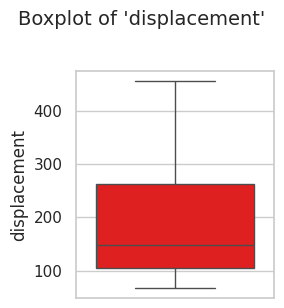

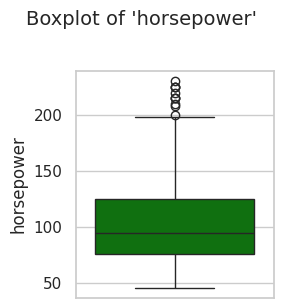

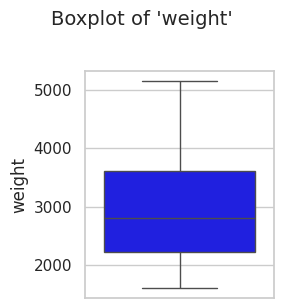

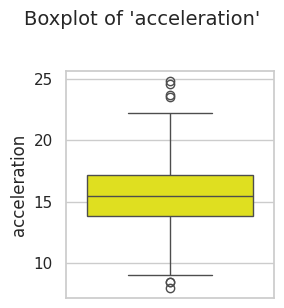

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global aesthetic style for all subsequent plots to a clean, gridded look
sns.set(style="whitegrid")

# Define a pool of colors to assign to each individual plot
colors = ['Red', 'Green', 'Blue', 'Yellow']

# Pair up the numeric columns and colors using zip(), then loop through them together
for numeric_col, color in zip(numeric_cols, colors):

    # Create a fresh, independent canvas window for this specific column's plot
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))

    # Draw a single, vertical boxplot where:
    # - data: The source DataFrame containing the car dataset
    # - y: The numerical column being analyzed, mapped to the vertical axis
    # - color: The unique solid color assigned to this specific plot from our colors list
    # - ax: Explicitly directs Seaborn to draw inside our newly sized figure axis
    sns.boxplot(data=car_data, y=numeric_col, color=color, ax=ax)

    # Place a centered main title above the plot, nudging it upward (y=1.02) so it does not collide with the chart
    plt.suptitle(f"Boxplot of '{numeric_col}'", fontsize=14, y=1.02)

    # Automatically adjust subplot padding and labels so nothing gets cut off at the edges
    plt.tight_layout()

    # Render the completed plot to the screen and clear the active figure state for the next loop iteration
    plt.show()

## **Box Plot - Class Based Coloring**

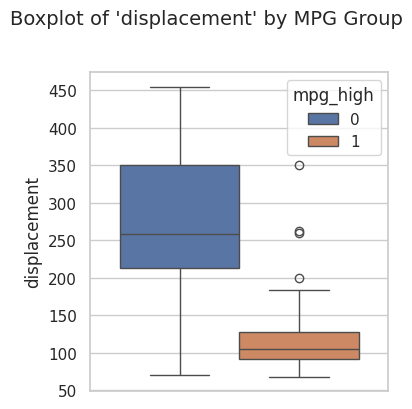

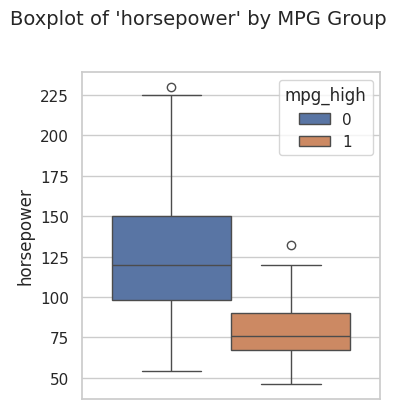

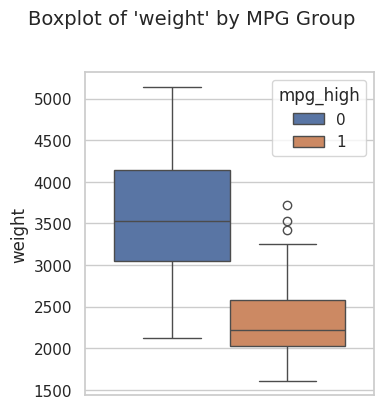

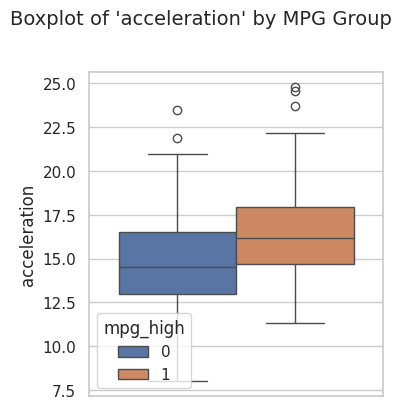

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global aesthetic style for all subsequent plots to a clean, gridded look
sns.set(style="whitegrid")

# Loop through each numerical column name in the predefined list
for numeric_col in numeric_cols:

    # Create a fresh, independent canvas window for this specific column's plot
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    # Draw a grouped, vertical boxplot where:
    # - data: The source DataFrame containing the car dataset
    # - y: The numerical column being analyzed, mapped to the vertical axis
    # - hue: Splits the data into side-by-side boxplots colored by the 'mpg_high' category
    # - ax: Explicitly directs Seaborn to draw inside our newly sized figure axis
    sns.boxplot(data=car_data, y=numeric_col, hue='mpg_high', ax=ax)

    # Place a centered main title above the plot, nudging it upward (y=1.02) so it does not collide with the chart
    plt.suptitle(f"Boxplot of '{numeric_col}' by MPG Group", fontsize=14, y=1.02)

    # Automatically adjust subplot padding and labels so nothing gets cut off at the edges
    plt.tight_layout()

    # Render the completed plot to the screen and clear the active figure state for the next loop iteration
    plt.show()

# **2. Violin Plot**


# 🎻 Why do we use a Violin Plot in EDA?

A **Violin Plot** is used to understand the distribution of a **numerical feature**. It combines the features of a **Box Plot** and a **KDE Plot**, showing both the **data spread** and the **distribution shape** in a single visualization.

## 🎯 Uses of Violin Plot

* 📊 **Understand the data distribution**

  * Visualize the overall shape of the data using a smooth density curve.

* 📍 **Identify where most values are concentrated**

  * Wider sections of the violin indicate a higher concentration of data points.

* 📦 **View summary statistics**

  * Display the median and quartiles (similar to a Box Plot).

* 🚨 **Detect outliers**

  * Identify unusual values that are far from the rest of the data.

* 🔍 **Compare distributions across categories**

  * Compare how a numerical feature is distributed for different groups.

## 🌍 Real-World Example

Consider the **Salary** column grouped by **Department**.

* 🎻 Each violin represents the salary distribution of one department.
* 📍 Wider areas indicate salary ranges where more employees are present.
* 📦 The center of the violin shows the median and quartiles.
* 📈 You can easily compare whether one department has a wider salary range than another.
* 🚨 Unusual salary values may appear as outliers.

## 💡 Key Takeaway

A Violin Plot helps answer questions such as:

* ❓ How is the data distributed?
* 📍 Where are most values concentrated?
* 📦 What are the median and quartiles?
* 🚨 Are there any outliers?
* 🔍 How do different groups compare?


## **Violin Plot**

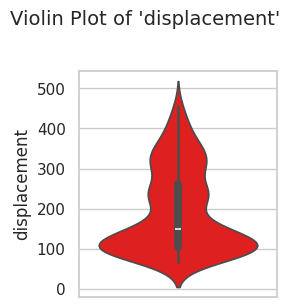

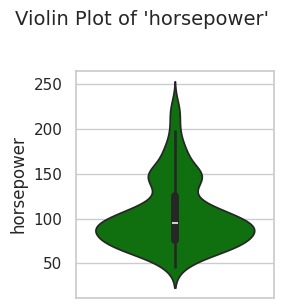

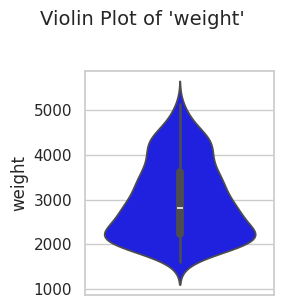

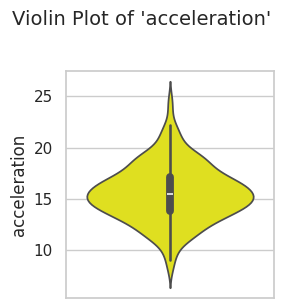

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global aesthetic style for all subsequent plots to a clean, gridded look
sns.set(style="whitegrid")

# Define a pool of colors to assign to each individual plot
colors = ['Red', 'Green', 'Blue', 'Yellow']

# Pair up the numeric columns and colors using zip(), then loop through them together
for numeric_col, color in zip(numeric_cols, colors):

    # Create a fresh, independent canvas window for this specific column's plot
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))

    # Draw a single, vertical violin plot where:
    # - data: The source DataFrame containing the car dataset
    # - y: The numerical column being analyzed, mapped to the vertical axis
    # - color: The unique solid color assigned to this specific plot from our colors list
    # - ax: Explicitly directs Seaborn to draw inside our newly sized figure axis
    sns.violinplot(data=car_data, y=numeric_col, color=color, ax=ax)

    # Place a centered main title above the plot, nudging it upward (y=1.02) so it does not collide with the chart
    plt.suptitle(f"Violin Plot of '{numeric_col}'", fontsize=14, y=1.02)

    # Automatically adjust subplot padding and labels so nothing gets cut off at the edges
    plt.tight_layout()

    # Render the completed plot to the screen and clear the active figure state for the next loop iteration
    plt.show()

## **Violin Plot - Class Based Coloring**

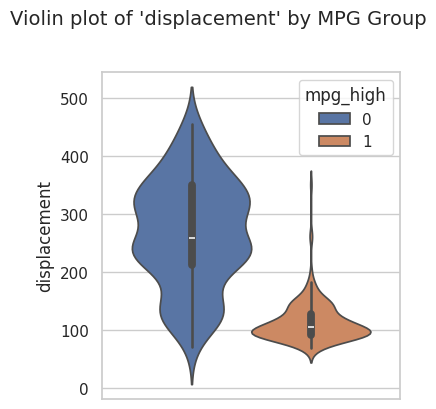

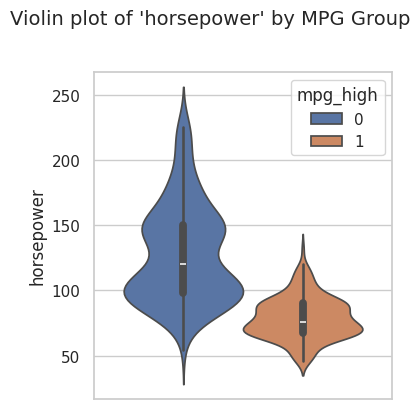

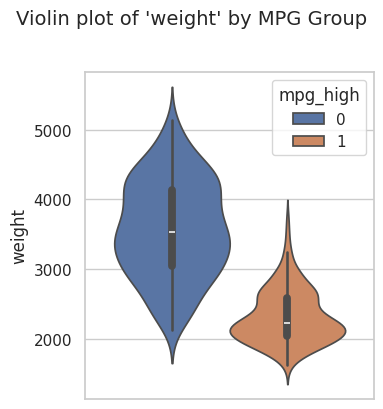

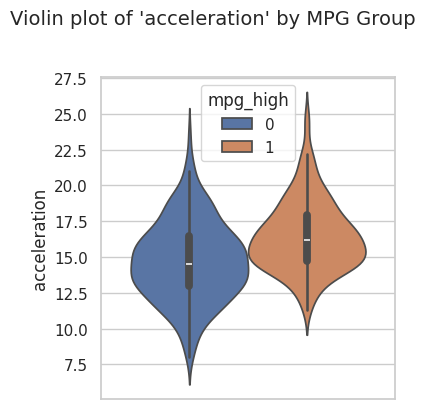

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the global aesthetic style for all subsequent plots to a clean, gridded look
sns.set(style="whitegrid")

# Loop through each numerical column name in the predefined list
for numeric_col in numeric_cols:

    # Create a fresh, independent canvas window for this specific column's plot
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    # Draw a grouped, vertical violin plot where:
    # - data: The source DataFrame containing the car dataset
    # - y: The numerical column being analyzed, mapped to the vertical axis
    # - hue: Splits the data into side-by-side violin plots colored by the 'mpg_high' category
    # - ax: Explicitly directs Seaborn to draw inside our newly sized figure axis
    sns.violinplot(data=car_data, y=numeric_col, hue='mpg_high', ax=ax)

    # Place a centered main title above the plot, nudging it upward (y=1.02) so it does not collide with the chart
    plt.suptitle(f"Violin plot of '{numeric_col}' by MPG Group", fontsize=14, y=1.02)

    # Automatically adjust subplot padding and labels so nothing gets cut off at the edges
    plt.tight_layout()

    # Render the completed plot to the screen and clear the active figure state for the next loop iteration
    plt.show()

# **3. Heatmap**


# 🔥 Why do we use a Heatmap in EDA?

A **Heatmap** is used to visualize the **correlation between numerical features** using colors. It helps identify which features are **strongly related**, **weakly related**, or **not related**.

## 🎯 Uses of Heatmap

* 🔗 **Understand feature correlation**

  * Check how strongly two numerical features are related.

* 📈 **Identify positive correlation**

  * A value close to **+1** means both features increase or decrease together.

* 📉 **Identify negative correlation**

  * A value close to **-1** means one feature increases while the other decreases.

* 🚫 **Identify no correlation**

  * A value close to **0** means there is little or no relationship between the features.

* 🎯 **Detect multicollinearity**

  * Identify highly correlated features that may need to be removed before building a machine learning model.

## 🌍 Real-World Example

Consider a dataset with **Height**, **Weight**, **Age**, and **Salary**.

* 🔥 The Heatmap displays the correlation between every pair of numerical features.
* 📈 **Height** and **Weight** may have a strong positive correlation.
* 📉 **Age** and **Exercise Hours** may have a negative correlation.
* 🚫 **Salary** and **Shoe Size** may show little or no correlation.
* 🎨 Darker colors usually indicate stronger relationships.

## 💡 Key Takeaway

A Heatmap helps answer questions such as:

* ❓ Which features are strongly correlated?
* 📈 Which features have a positive correlation?
* 📉 Which features have a negative correlation?
* 🚫 Which features have little or no correlation?
* 🎯 Are there highly correlated features that should be removed?


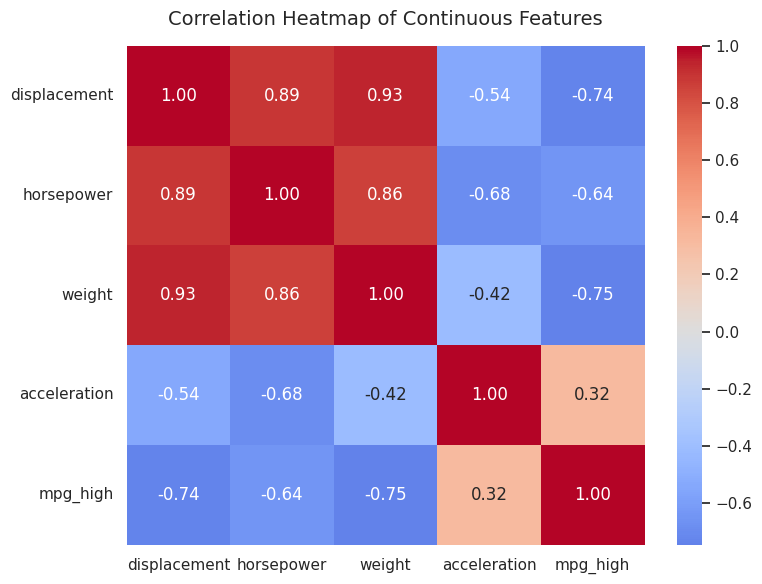

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Explicitly define the subset of continuous numerical features we want to analyze
numeric_cols_all = ['displacement', 'horsepower', 'weight', 'acceleration', 'mpg_high']

# Compute the Pearson correlation matrix strictly for our selected subset of columns
# Note: Slicing car_data[...] guarantees no extra numerical columns sneak into the matrix
corr_matrix = car_data[numeric_cols_all].corr()
#corr_matrix = car_data.corr(numeric_only=True)
# Create a fresh canvas window with a balanced 8x6 inch ratio
plt.figure(figsize=(8, 6))

# Draw the correlation heatmap where:
# - data: The calculated square correlation matrix dataframe
# - annot=True: Overlays the exact numerical correlation coefficients inside each cell
# - cmap='coolwarm': Applies a diverging color scale (blue for negative, red for positive correlation)
# - center=0: Anchors the neutral point of the color palette to 0 (perfectly white/neutral grey)
# - fmt=".2f": Rounds the overlaid text coefficients to exactly 2 decimal places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")

# Place a clean, bold title above the heatmap chart
plt.title("Correlation Heatmap of Continuous Features", fontsize=14, pad=15)

# Automatically adjust the figure boundaries so axis names and values aren't clipped
plt.tight_layout()

# Render the completed heatmap onto the screen
plt.show()